# Fairness-Aware Hospital Readmission Prediction

This notebook compares a baseline Random Forest, a tuned Random Forest, adversarial debiasing, and ThresholdOptimizer on the Fairlearn Diabetes Hospital dataset. The sensitive attribute is `gender`, and the analysis focuses on both predictive performance and group disparities.


In [1]:
%%capture
!pip install fairlearn


In [2]:
# Load modules
import numpy as np
from IPython.display import display, Markdown, Latex
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score

from fairlearn.postprocessing import ThresholdOptimizer
from fairlearn.preprocessing import CorrelationRemover
from fairlearn.adversarial import AdversarialFairnessClassifier
from fairlearn.metrics import MetricFrame
import fairlearn.datasets as fdata
from fairlearn.metrics import (demographic_parity_difference, demographic_parity_ratio,
                               selection_rate_difference, false_negative_rate_difference,
                               false_positive_rate_difference, equalized_odds_ratio,
                               false_negative_rate, false_positive_rate)


## Data and preprocessing

The target is hospital readmission. Target-related columns are removed from the predictors, and a reproducible sample is used to keep the experiments manageable.


In [3]:
# Load and read about the dataset.
# get datast from fairlearn and show description
dataset = fdata.fetch_diabetes_hospital()

display(Markdown(dataset.DESCR))

# save dataframe and features
x_raw = dataset.data
# y_raw = np.array(dataset.target)
feature_names = dataset.feature_names


The "Diabetes 130-Hospitals" dataset represents 10 years of clinical care at 130 U.S. hospitals and delivery networks, collected from 1999 to 2008. Each record represents the hospital admission record for a patient diagnosed with diabetes whose stay lasted between one to fourteen days. The features describing each encounter include demographics, diagnoses, diabetic medications, number of visits in the year preceding the encounter, and payer information, as well as whether the patient was readmitted after release, and whether the readmission occurred within 30 days of the release.

The original "Diabetes 130-Hospitals" dataset was collected by Beata Strack, Jonathan P. DeShazo, Chris Gennings, Juan L. Olmo, Sebastian Ventura, Krzysztof J. Cios, and John N. Clore in 2014.

This version of the dataset was derived by the Fairlearn team for the SciPy 2021 tutorial "Fairness in AI Systems: From social context to practice using Fairlearn". In this version, the target variable "readmitted" is binarized into whether the patient was re-admitted within thirty days. The full dataset pre-processing script can be found on GitHub: https://github.com/fairlearn/talks/blob/main/2021_scipy_tutorial/preprocess.py

Downloaded from openml.org.

The dataset contains two variables, `readmitted` and `readmit_binary`, that encode the outcome. To avoid target leakage, both are removed from the predictor set after extracting `readmit_binary` as the target.

For computational efficiency, I work with a reproducible 10% sample of the original dataset. This keeps the notebook practical to rerun while preserving the full modeling workflow.


In [4]:
# Down sample to make runtimes reasonable
x_raw = x_raw.sample(frac=0.1, random_state=123)


In [5]:
y_raw = x_raw['readmit_binary']
x_raw = x_raw.drop(columns=['readmitted', 'readmit_binary'])
feature_names = feature_names[:-2]


In [6]:
# Look at the first few rows of the data.
x_raw.head()


,race,gender,age,discharge_disposition_id,admission_source_id,time_in_hospital,medical_specialty,num_lab_procedures,num_procedures,num_medications,...,max_glu_serum,A1Cresult,insulin,change,diabetesMed,medicare,medicaid,had_emergency,had_inpatient_days,had_outpatient_days
65884,Caucasian,Male,'Over 60 years','Discharged to Home',Emergency,3,Missing,49,6,27,...,None,None,Up,Ch,Yes,False,False,False,True,False
86278,Caucasian,Female,'Over 60 years',Other,Referral,5,Missing,57,0,21,...,None,None,No,Ch,Yes,True,False,False,True,False
30000,Caucasian,Male,'30-60 years','Discharged to Home',Other,4,Other,37,2,9,...,None,None,No,No,No,False,False,False,False,False
51185,Caucasian,Male,'30-60 years',Other,Other,9,InternalMedicine,61,6,27,...,None,>8,No,Ch,Yes,False,False,True,False,True
53902,Caucasian,Female,'30-60 years','Discharged to Home',Referral,7,Other,23,0,13,...,None,None,No,No,Yes,True,False,True,True,False


## Data inspection




In [7]:
# drop the rows with 'Unknown/Invalid' values for gender

# drop these 3 rows
print(x_raw.shape)
rows_to_keep = x_raw.gender != 'Unknown/Invalid'
x_raw = x_raw[rows_to_keep]
y_raw = y_raw[rows_to_keep]
print(x_raw.shape)


(10177, 22)
(10177, 22)


In [8]:
unique_feature_values = x_raw.apply(np.unique, axis=0)
unique_feature_values


,0
race,"[AfricanAmerican, Asian, Caucasian, Hispanic, ..."
gender,"[Female, Male]"
age,"['30 years or younger', '30-60 years', 'Over 6..."
discharge_disposition_id,"['Discharged to Home', Other]"
admission_source_id,"[Emergency, Other, Referral]"
time_in_hospital,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]"
medical_specialty,"[Cardiology, Emergency/Trauma, Family/GeneralP..."
num_lab_procedures,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14..."
num_procedures,"[0, 1, 2, 3, 4, 5, 6]"
num_medications,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14..."


In [9]:
PALETTE = sns.color_palette("Set2", 6)


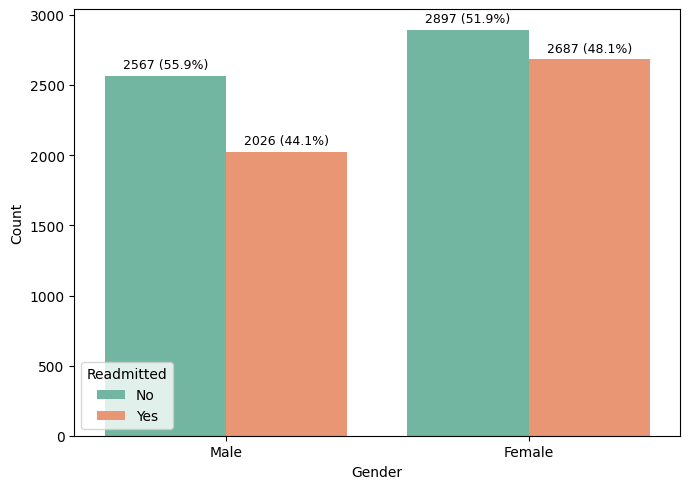

In [14]:
df_plot = pd.DataFrame({
    'Gender': x_raw['gender'],
    'Readmitted': y_raw
})

fig, ax = plt.subplots(figsize=(7, 5))

sns.countplot(
    data=df_plot,
    x='Gender',
    hue='Readmitted',
    order=['Male', 'Female'],
    palette=[PALETTE[0], PALETTE[1]],
    ax=ax
)

ax.set_xlabel('Gender')
ax.set_ylabel('Count')
ax.legend(title='Readmitted', labels=['No', 'Yes'])

# Total per gender
gender_totals = df_plot.groupby('Gender').size()

# Add count + percentage within each gender
for container in ax.containers:
    for bar in container:
        height = bar.get_height()

        if height > 0:
            x_center = bar.get_x() + bar.get_width() / 2

            # x=0 -> Male, x=1 -> Female
            gender = ['Male', 'Female'][int(round(x_center))]

            percentage = height / gender_totals[gender] * 100

            ax.annotate(
                f'{int(height)} ({percentage:.1f}%)',
                (x_center, height),
                ha='center',
                va='bottom',
                fontsize=9,
                xytext=(0, 3),
                textcoords='offset points'
            )

plt.tight_layout()
plt.show()

In [16]:
gender_proportions = df_plot.groupby('Gender')['Readmitted'].value_counts(normalize=True).unstack()
print("Proportion of Gender by Readmission Status:")
print(gender_proportions)

Proportion of Gender by Readmission Status:
Readmitted         0         1
Gender                        
Female      0.518804  0.481196
Male        0.558894  0.441106


The female group has a slightly higher readmission rate (**48.1% vs 44.1%**), the groups are therefore not identical, but the outcome is not strongly imbalanced by gender.so group-specific error rates are worth checking even before applying fairness interventions.


In [17]:
binary_features = unique_feature_values.index[[len(x) == 2 for x in unique_feature_values]].values
print(f'Binary features: {binary_features}')
categorical_features = unique_feature_values.index[[len(x) > 2 and isinstance(x[0], str) for x in unique_feature_values]].values
print(f'Categorical features: {categorical_features}')


Binary features: ['gender' 'discharge_disposition_id' 'change' 'diabetesMed' 'medicare'
 'medicaid' 'had_emergency' 'had_inpatient_days' 'had_outpatient_days']
Categorical features: ['race' 'age' 'admission_source_id' 'medical_specialty'
 'primary_diagnosis' 'max_glu_serum' 'A1Cresult' 'insulin']


In [18]:
# standardize data types
for col_name in feature_names:
    if col_name in categorical_features:
        x_raw[col_name] = x_raw[col_name].astype('category')
    elif col_name in binary_features:  # redundant for clarity
        # turn into int column
        integer_col = (x_raw[col_name] == unique_feature_values[col_name][0]).astype(int)
        new_name = f'{col_name}_{unique_feature_values[col_name][0]}'
        x_raw[new_name] = integer_col
        x_raw.drop(columns=[col_name], inplace=True)


In [19]:
%%capture
x_raw.apply(np.unique, axis=0)


In [20]:
x_raw.dtypes


,0
race,category
age,category
admission_source_id,category
time_in_hospital,int64
medical_specialty,category
num_lab_procedures,int64
num_procedures,int64
num_medications,int64
primary_diagnosis,category
number_diagnoses,int64


In [21]:
# One-hot encode categorical features
x_numeric = pd.get_dummies(x_raw)
display(x_numeric.head())

# get one-hot and numeric column names
numeric_cols = x_numeric.dtypes.index[x_numeric.dtypes == 'int64'].values
one_hot_cols = x_numeric.dtypes.index[x_numeric.dtypes != 'int64'].values


,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_diagnoses,gender_Female,discharge_disposition_id_'Discharged to Home',change_Ch,diabetesMed_No,medicare_False,...,max_glu_serum_None,max_glu_serum_Norm,A1Cresult_>7,A1Cresult_>8,A1Cresult_None,A1Cresult_Norm,insulin_Down,insulin_No,insulin_Steady,insulin_Up
65884,3,49,6,27,9,0,1,1,0,1,...,True,False,False,False,True,False,False,False,False,True
86278,5,57,0,21,9,1,0,1,0,0,...,True,False,False,False,True,False,False,True,False,False
30000,4,37,2,9,5,0,1,0,1,1,...,True,False,False,False,True,False,False,True,False,False
51185,9,61,6,27,9,0,0,1,0,1,...,True,False,False,True,False,False,False,True,False,False
53902,7,23,0,13,7,1,1,0,0,0,...,True,False,False,False,True,False,False,True,False,False


## Train/test split

Models are evaluated on a held-out **20% test set**.


In [22]:

X_train, X_test, y_train, y_test = train_test_split(x_numeric, y_raw, test_size=0.2, random_state=42 )


## 1. Baseline Random Forest

A one-tree Random Forest provides a simple reference model before tuning or fairness mitigation.


In [23]:
# initialize a model with RandomForestClassifier
n_estimators = 1

# train the model with the training data split
rfc_model = RandomForestClassifier(n_estimators=1, random_state=42)
rfc_model.fit(X_train, y_train)


RandomForestClassifier(n_estimators=1, random_state=42)

### Metrics

I report Accuracy, Precision, Recall, FNR, and FPR overall and by gender using `MetricFrame`.


Fairness is summarized with FNR/FPR differences, demographic parity ratio, equalized odds ratio, and selection-rate difference.


In [24]:

# get model's prediction for the test set
y_pred_baseline = rfc_model.predict(X_test)

# use MetricFrame to get the results

metric_dict = {
    'Accuracy': accuracy_score,
    'Precision': precision_score,
    'Recall': recall_score,
    'FNR': false_negative_rate,
    'FPR': false_positive_rate}
sample_params = {}

metric_frame_baseline = MetricFrame(
    metrics=metric_dict,
    y_true=y_test,
    y_pred=y_pred_baseline,
    sensitive_features=X_test['gender_Female'],
    sample_params=sample_params
)


In [25]:
# Overall metrics
print("=== Overall metrics ===")
print(metric_frame_baseline.overall)

# Group-specific metrics
print("\n=== Metrics by gender ===")
print(metric_frame_baseline.by_group)


=== Overall metrics ===
Accuracy     0.546169
Precision    0.503582
Recall       0.528464
FNR          0.471536
FPR          0.438914
dtype: float64

=== Metrics by gender ===
               Accuracy  Precision    Recall       FNR       FPR
gender_Female                                                   
0              0.550379   0.495238  0.506083  0.493917  0.414062
1              0.542677   0.509874  0.546154  0.453846  0.460371


In [26]:
fnr_diff_baseline = false_negative_rate_difference(y_test, y_pred_baseline, sensitive_features=X_test['gender_Female'])
fpr_diff_baseline = false_positive_rate_difference(y_test, y_pred_baseline, sensitive_features=X_test['gender_Female'])
dp_ratio_baseline = demographic_parity_ratio(y_test, y_pred_baseline, sensitive_features=X_test['gender_Female'])
eo_ratio_baseline = equalized_odds_ratio(y_test, y_pred_baseline, sensitive_features=X_test['gender_Female'])
sel_diff_baseline = selection_rate_difference(y_test, y_pred_baseline, sensitive_features=X_test['gender_Female'])

print("\n=== Fairness Metrics ===")
print(f"FNR Difference: {fnr_diff_baseline:.4f}")
print(f"FPR Difference: {fpr_diff_baseline:.4f}")
print(f"Demographic Parity Ratio: {dp_ratio_baseline:.4f}")
print(f"Equalized Odds Ratio: {eo_ratio_baseline:.4f}")
print(f"Selection Rate Difference: {sel_diff_baseline:.4f}")

metrics_baseline = {
    'overall': metric_frame_baseline.overall.to_dict(),
    'FNR_diff': fnr_diff_baseline,
    'FPR_diff': fpr_diff_baseline,
    'DP_ratio': dp_ratio_baseline,
    'EO_ratio': eo_ratio_baseline,
    'Sel_diff': sel_diff_baseline,
}



=== Fairness Metrics ===
FNR Difference: 0.0401
FPR Difference: 0.0463
Demographic Parity Ratio: 0.9093
Equalized Odds Ratio: 0.8994
Selection Rate Difference: 0.0454


### Baseline result

Overall accuracy is **0.546**. Males have slightly higher accuracy (**0.550 vs 0.543**), while females have higher recall (**0.546 vs 0.506**) and lower FNR (**0.454 vs 0.494**). Males have the lower FPR (**0.414 vs 0.460**). The baseline therefore has similar overall performance across groups, but the types of errors differ.


## 2. Tuned Random Forest

The tuned model uses `n_estimators=1000` and `max_depth=10`, selected to improve accuracy.


In [27]:
n_estimators = 1000
max_depth = 10
rfc_model_optimized = RandomForestClassifier(n_estimators=1000, max_depth = 10, random_state=42)
rfc_model_optimized.fit(X_train, y_train)


RandomForestClassifier(max_depth=10, n_estimators=1000, random_state=42)

In [28]:
# get model's prediction for the test set
y_pred_optimized = rfc_model_optimized.predict(X_test)

# use MetricFrame to get the results

metric_dict = {
    'Accuracy': accuracy_score,
    'Precision': precision_score,
    'Recall': recall_score,
    'FNR': false_negative_rate,
    'FPR': false_positive_rate}
sample_params = {}

metric_frame = MetricFrame(
    metrics=metric_dict,
    y_true=y_test,
    y_pred=y_pred_optimized,
    sensitive_features=X_test['gender_Female'],
    sample_params=sample_params
)


In [29]:
# Overall metrics
print("=== Overall metrics ===")
print(metric_frame.overall)

# Group-specific metrics
print("\n=== Metrics by gender ===")
print(metric_frame.by_group)


=== Overall metrics ===
Accuracy     0.600196
Precision    0.583452
Recall       0.439313
FNR          0.560687
FPR          0.264253
dtype: float64

=== Metrics by gender ===
               Accuracy  Precision    Recall       FNR      FPR
gender_Female                                                  
0              0.596966   0.566102  0.406326  0.593674  0.25000
1              0.602875   0.596059  0.465385  0.534615  0.27656


### Fairness after tuning

The tuned model is evaluated with the same fairness metrics to see whether higher predictive performance also reduces group disparities.


In [30]:
fnr_diff = false_negative_rate_difference(y_test, y_pred_optimized, sensitive_features=X_test['gender_Female'])
fpr_diff = false_positive_rate_difference(y_test, y_pred_optimized, sensitive_features=X_test['gender_Female'])
dp_ratio = demographic_parity_ratio(y_test, y_pred_optimized, sensitive_features=X_test['gender_Female'])
eo_ratio = equalized_odds_ratio(y_test, y_pred_optimized, sensitive_features=X_test['gender_Female'])
sel_diff = selection_rate_difference(y_test, y_pred_optimized, sensitive_features=X_test['gender_Female'])

print("\n=== Fairness Metrics ===")
print(f"FNR Difference: {fnr_diff:.4f}")
print(f"FPR Difference: {fpr_diff:.4f}")
print(f"Demographic Parity Ratio: {dp_ratio:.4f}")
print(f"Equalized Odds Ratio: {eo_ratio:.4f}")
print(f"Selection Rate Difference: {sel_diff:.4f}")



=== Fairness Metrics ===
FNR Difference: 0.0591
FPR Difference: 0.0266
Demographic Parity Ratio: 0.8762
Equalized Odds Ratio: 0.8731
Selection Rate Difference: 0.0452


### Effect of tuning

Accuracy improves from **0.546 to 0.600** and precision from **0.504 to 0.583**. FPR drops from **0.439 to 0.264**, but recall falls from **0.528 to 0.439**, increasing FNR from **0.472 to 0.561**.

Fairness also shifts: FPR difference improves (**0.046 → 0.027**), but FNR difference worsens (**0.040 → 0.059**). Tuning therefore improves overall accuracy while missing more true readmissions.


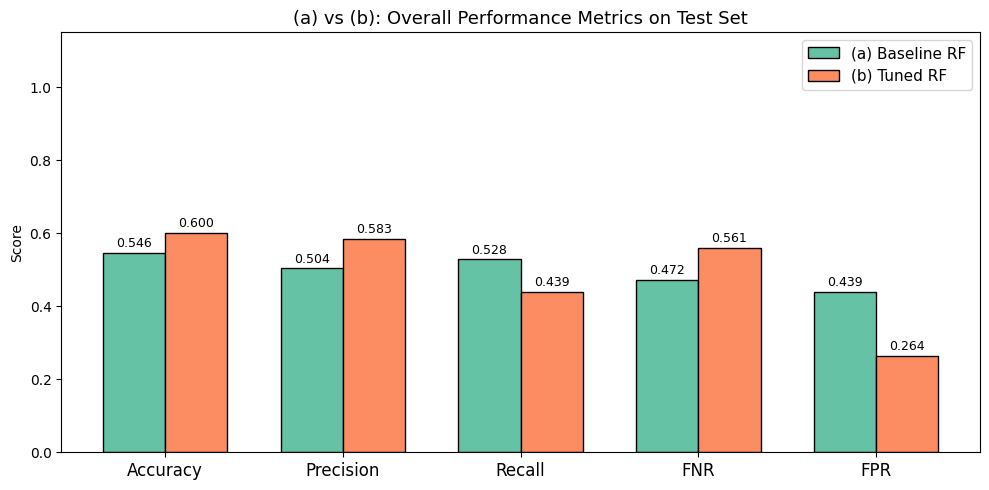

In [31]:
overall_metrics_names = list(metric_dict.keys())
vals_a_ov = [metric_frame_baseline.overall[k] for k in overall_metrics_names]
vals_b_ov = [metric_frame.overall[k] for k in overall_metrics_names]

x_pos = np.arange(len(overall_metrics_names))
width = 0.35
fig, ax = plt.subplots(figsize=(10, 5))
b1 = ax.bar(x_pos - width/2, vals_a_ov, width, label='(a) Baseline RF', color=PALETTE[0], edgecolor='black')
b2 = ax.bar(x_pos + width/2, vals_b_ov, width, label='(b) Tuned RF', color=PALETTE[1], edgecolor='black')
ax.set_xticks(x_pos); ax.set_xticklabels(overall_metrics_names, fontsize=12)
ax.set_ylabel('Score'); ax.set_ylim(0, 1.15)
ax.set_title('(a) vs (b): Overall Performance Metrics on Test Set', fontsize=13)
ax.legend(fontsize=11)
ax.bar_label(b1, fmt='%.3f', fontsize=9, padding=2)
ax.bar_label(b2, fmt='%.3f', fontsize=9, padding=2)
plt.tight_layout()
plt.show()


### Group-wise comparison

After tuning, females have higher accuracy, precision, and recall, while males still have the lower FPR.


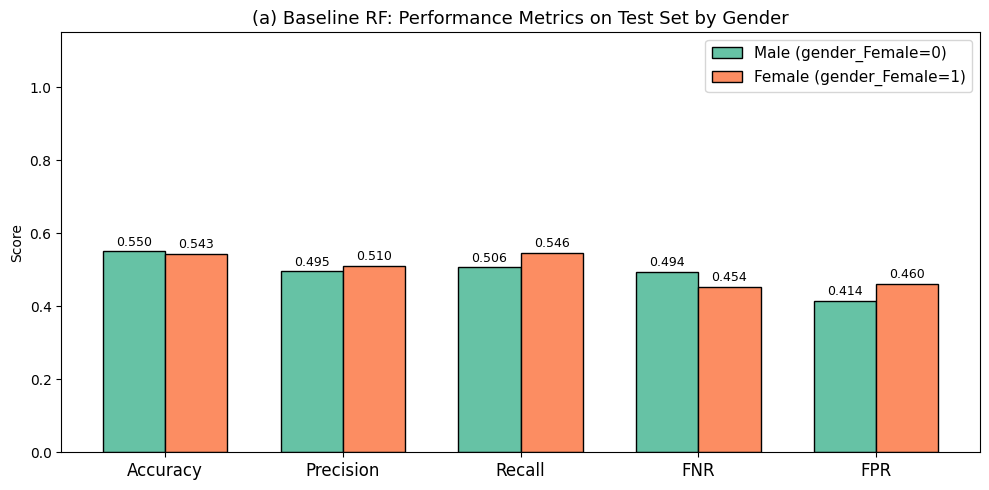

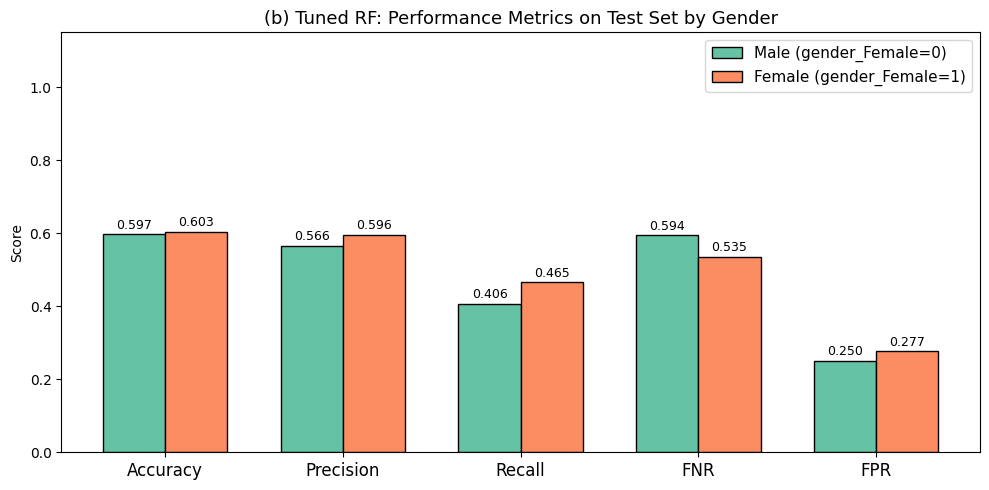

In [32]:
model_data = {
    '(a) Baseline RF': metric_frame_baseline.by_group,
    '(b) Tuned RF': metric_frame.by_group
}

# Removed model_colors dictionary as colors will be consistent for gender across models

for model_name, metrics_df in model_data.items():
    fig, ax = plt.subplots(figsize=(10, 5))

    # Extract metrics for Male (gender_Female = 0) and Female (gender_Female = 1)
    vals_male = [metrics_df.loc[0][k] for k in overall_metrics_names]
    vals_female = [metrics_df.loc[1][k] for k in overall_metrics_names]

    x_pos = np.arange(len(overall_metrics_names))
    width = 0.35

    # Assign consistent colors for male and female across both models
    b1 = ax.bar(x_pos - width/2, vals_male, width, label='Male (gender_Female=0)', color=PALETTE[0], edgecolor='black')
    b2 = ax.bar(x_pos + width/2, vals_female, width, label='Female (gender_Female=1)', color=PALETTE[1], edgecolor='black')

    ax.set_xticks(x_pos)
    ax.set_xticklabels(overall_metrics_names, fontsize=12)
    ax.set_ylabel('Score')
    ax.set_ylim(0, 1.15)
    ax.set_title(f'{model_name}: Performance Metrics on Test Set by Gender', fontsize=13)
    ax.legend(fontsize=11)
    ax.bar_label(b1, fmt='%.3f', fontsize=9, padding=2)
    ax.bar_label(b2, fmt='%.3f', fontsize=9, padding=2)
    plt.tight_layout()
    plt.show()


## 3. Adversarial Fairness Classifier

The adversarial model is trained with `alpha ∈ {0.0, 0.3, 0.7, 1.0}` across several random seeds to study the fairness–performance trade-off.


In [33]:
FAIRNESS_FUNCS = {
    'FNR_diff': false_negative_rate_difference,
    'FPR_diff': false_positive_rate_difference,
    'DP_ratio': demographic_parity_ratio,
    'EO_ratio': equalized_odds_ratio,
    'Sel_diff': selection_rate_difference,
}
sensitive_test  = X_test['gender_Female']
sensitive_train = X_train['gender_Female']


In [34]:
def compute_all_metrics(y_true, y_pred, sensitive):
    mf = MetricFrame(
        metrics=metric_dict,
        y_true=y_true,
        y_pred=y_pred,
        sensitive_features=sensitive,
    )
    result = {}
    result['overall']  = mf.overall.to_dict()
    result['by_group'] = mf.by_group.to_dict()
    for name, fn in FAIRNESS_FUNCS.items():
        result[name] = fn(y_true, y_pred, sensitive_features=sensitive)
    return result


In [ ]:
# Fit the AdversarialFairnessClassifier here.
# Use these hyperparameters, while varying the `alpha` parameter:
# - backend='tensorflow',
# - predictor_model=[128,64,32,16,8],
# - adversary_model=[32,16,8],
# - learning_rate=0.001,
# - epochs=3,
# - batch_size=16,
# - constraints='demographic_parity',
# - random_state=seed,
# - shuffle=True

# Fit the AdversarialFairnessClassifier here.
ALPHAS = [0.0, 0.3, 0.7, 1.0]
SEEDS  = list(range(10))

afc_results = {
    a: {**{k: [] for k in metric_dict}, **{k: [] for k in FAIRNESS_FUNCS}}
    for a in ALPHAS
}

for alpha in ALPHAS:
    for seed in SEEDS:
        print(f"  Training AFC alpha={alpha}, seed={seed}", flush=True)
        clf = AdversarialFairnessClassifier(
            backend='tensorflow',
            predictor_model=[128, 64, 32, 16, 8],
            adversary_model=[32, 16, 8],
            learning_rate=0.001,
            epochs=3,
            batch_size=16,
            constraints='demographic_parity',
            random_state=seed,
            shuffle=True,
            alpha=alpha,
        )
        clf.fit(X_train.values, y_train, sensitive_features=sensitive_train)
        y_pred_afc = clf.predict(X_test.values)
        m = compute_all_metrics(y_test, y_pred_afc, sensitive_test)
        for k in metric_dict:
            afc_results[alpha][k].append(m['overall'][k])
        for k in FAIRNESS_FUNCS:
            afc_results[alpha][k].append(m[k])

print("\n AFC training complete.")


  Training AFC alpha=0.0, seed=0
  Training AFC alpha=0.0, seed=1
  Training AFC alpha=0.0, seed=2
  Training AFC alpha=0.0, seed=3
  Training AFC alpha=0.0, seed=4
  Training AFC alpha=0.0, seed=5
  Training AFC alpha=0.0, seed=6
  Training AFC alpha=0.0, seed=7
  Training AFC alpha=0.0, seed=8
  Training AFC alpha=0.0, seed=9
  Training AFC alpha=0.3, seed=0
  Training AFC alpha=0.3, seed=1
  Training AFC alpha=0.3, seed=2
  Training AFC alpha=0.3, seed=3
  Training AFC alpha=0.3, seed=4
  Training AFC alpha=0.3, seed=5
  Training AFC alpha=0.3, seed=6
  Training AFC alpha=0.3, seed=7
  Training AFC alpha=0.3, seed=8
  Training AFC alpha=0.3, seed=9
  Training AFC alpha=0.7, seed=0
  Training AFC alpha=0.7, seed=1
  Training AFC alpha=0.7, seed=2
  Training AFC alpha=0.7, seed=3
  Training AFC alpha=0.7, seed=4
  Training AFC alpha=0.7, seed=5
  Training AFC alpha=0.7, seed=6
  Training AFC alpha=0.7, seed=7
  Training AFC alpha=0.7, seed=8
  Training AFC alpha=0.7, seed=9
  Training

### Adversarial results

Across the tested `alpha` values, the adversarial models generally have **lower accuracy and precision than the tuned Random Forest, but higher recall**. They reduce FNR disparities, while FPR differences vary across `alpha`. The effect is therefore a redistribution of errors rather than a uniform improvement on every metric.


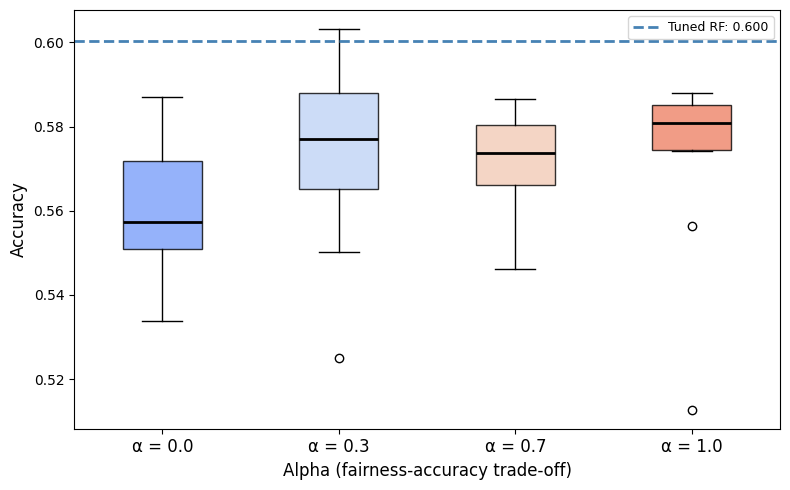

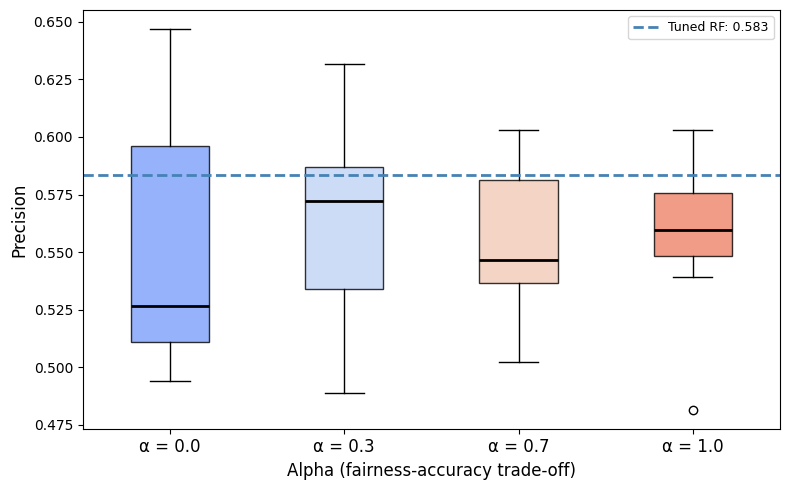

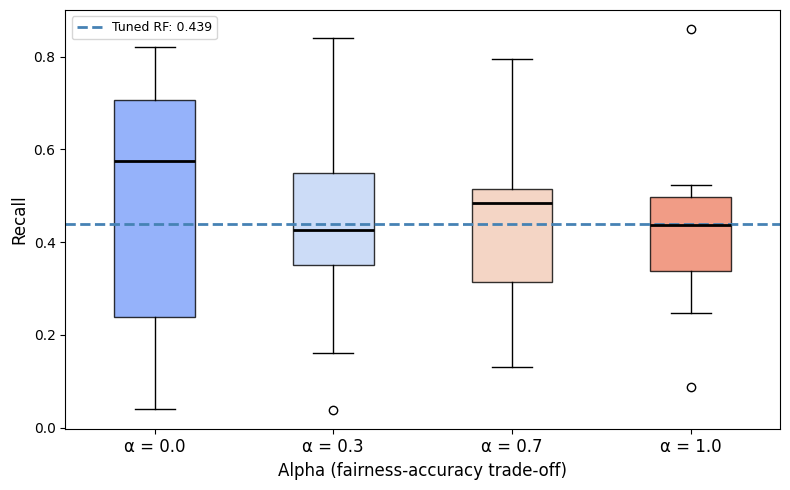

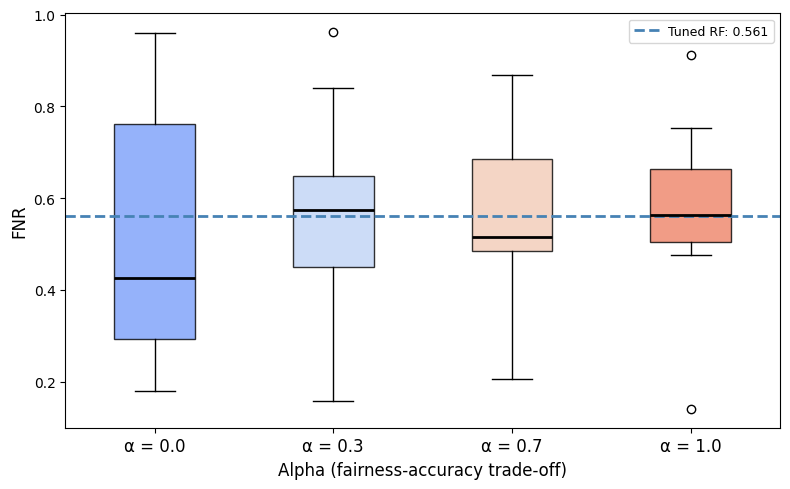

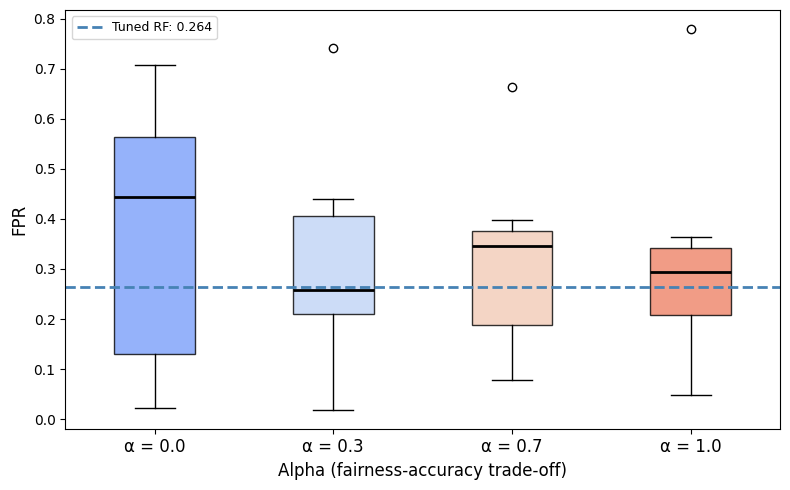

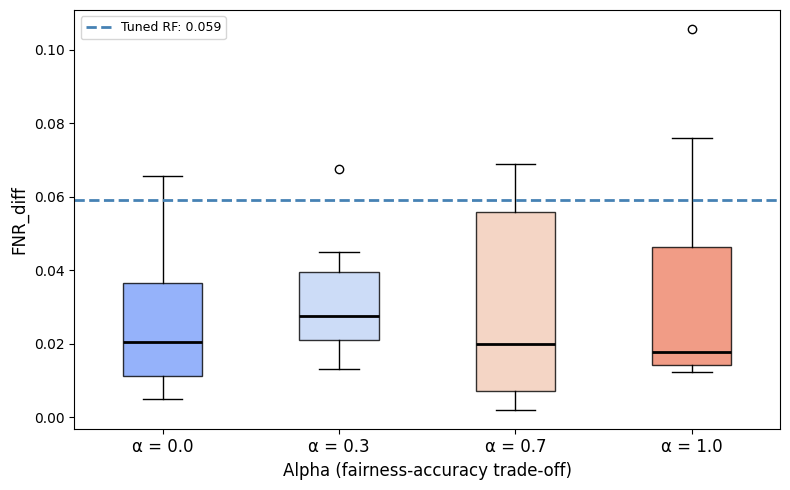

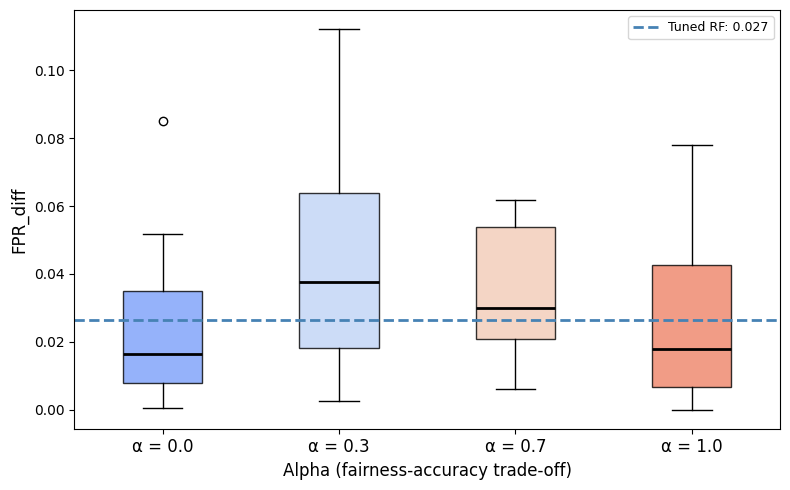

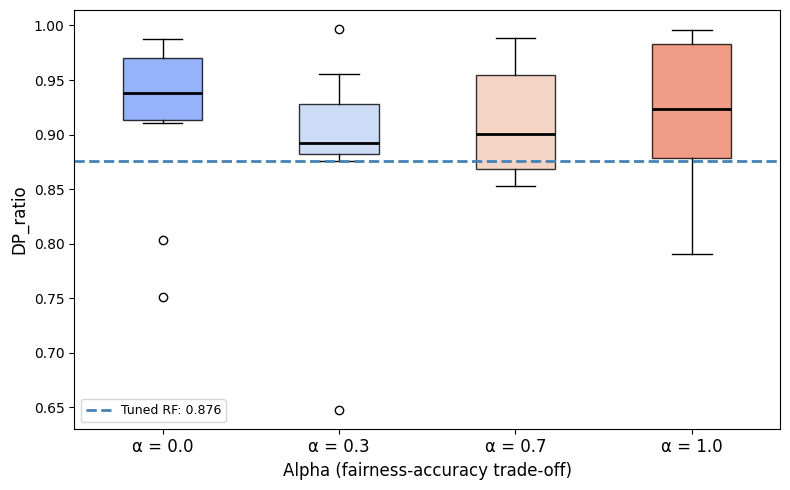

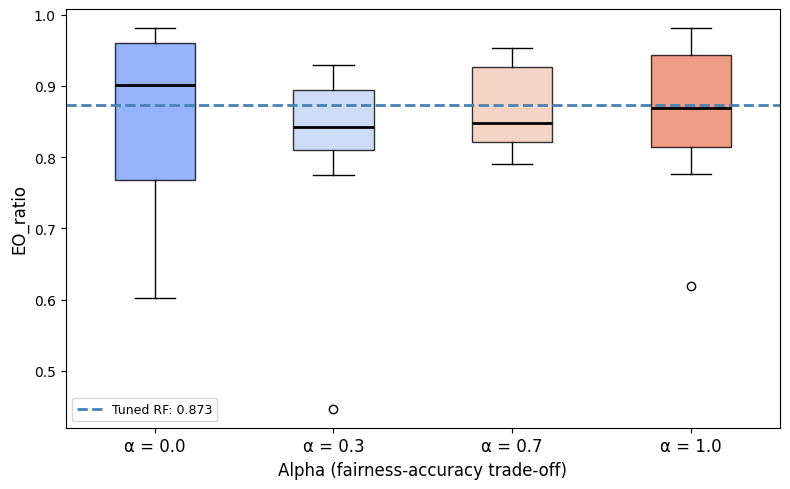

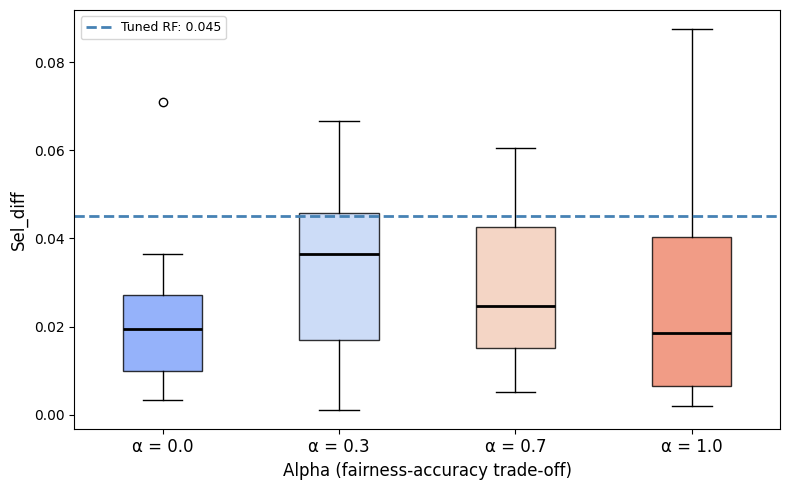

In [ ]:
# ### Plot all our metrics as line plots while varying alpha
all_metric_keys = list(metric_dict.keys()) + list(FAIRNESS_FUNCS.keys())

# Define metrics_tuned before the loop
metrics_tuned = {
    'overall': metric_frame.overall.to_dict(),
    'FNR_diff': fnr_diff,
    'FPR_diff': fpr_diff,
    'DP_ratio': dp_ratio,
    'EO_ratio': eo_ratio,
    'Sel_diff': sel_diff,
}

for metric in all_metric_keys:
    fig, ax = plt.subplots(figsize=(8, 5))
    data_per_alpha = [afc_results[a][metric] for a in ALPHAS]
    bp = ax.boxplot(data_per_alpha, positions=range(len(ALPHAS)),
                    patch_artist=True,
                    medianprops=dict(color='black', lw=2))
    colors = sns.color_palette("coolwarm", len(ALPHAS))
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.8)

    # Horizontal reference line: tuned RF
    if metric in metric_dict:
        tuned_val = metrics_tuned['overall'][metric]
    elif metric in FAIRNESS_FUNCS:
        tuned_val = metrics_tuned[metric]
    else:
        raise ValueError(f"Metric '{metric}' not found in tuned results.")

    ax.axhline(tuned_val, color='steelblue', ls='--', lw=2,
               label=f'Tuned RF: {tuned_val:.3f}')

    ax.set_xticks(range(len(ALPHAS)))
    ax.set_xticklabels([f'α = {a}' for a in ALPHAS], fontsize=12)
    ax.set_xlabel('Alpha (fairness-accuracy trade-off)', fontsize=12)
    ax.set_ylabel(metric, fontsize=12)
    #ax.set_title(f'AFC - {metric} across 10 Seeds and 4 Alpha Values', fontsize=12)
    ax.legend(fontsize=9)
    plt.tight_layout()
    plt.show()


## 4. ThresholdOptimizer

`ThresholdOptimizer` is applied to the tuned Random Forest with an **equalized odds** constraint, so both FPR and FNR are balanced across gender groups.


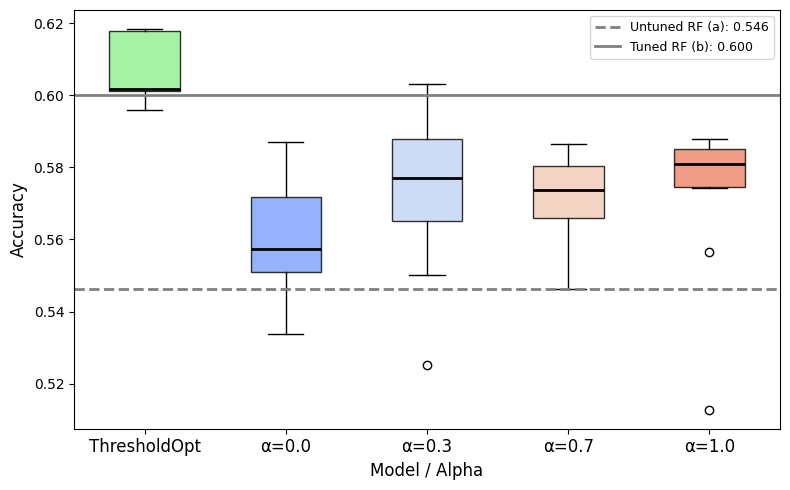

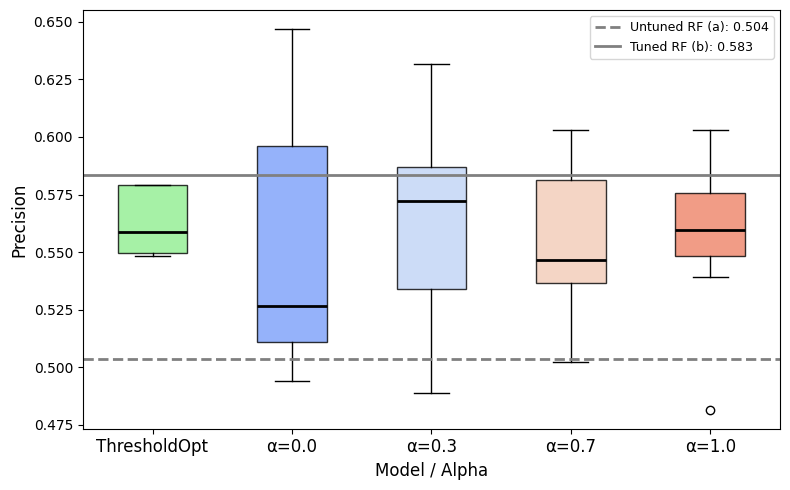

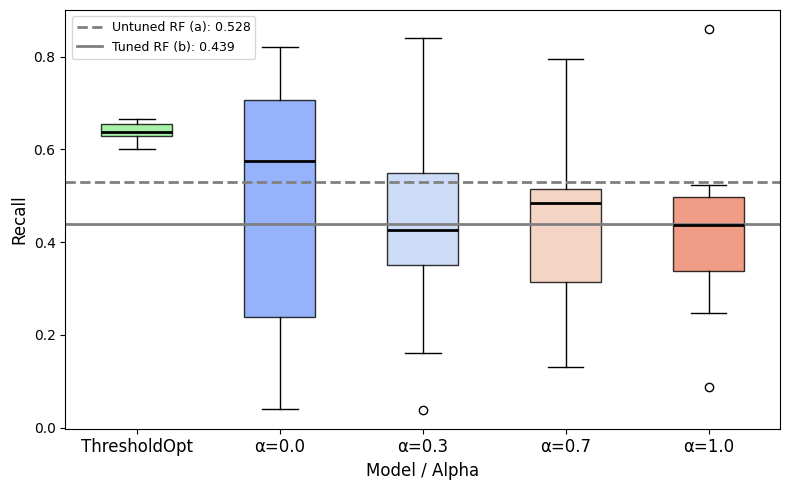

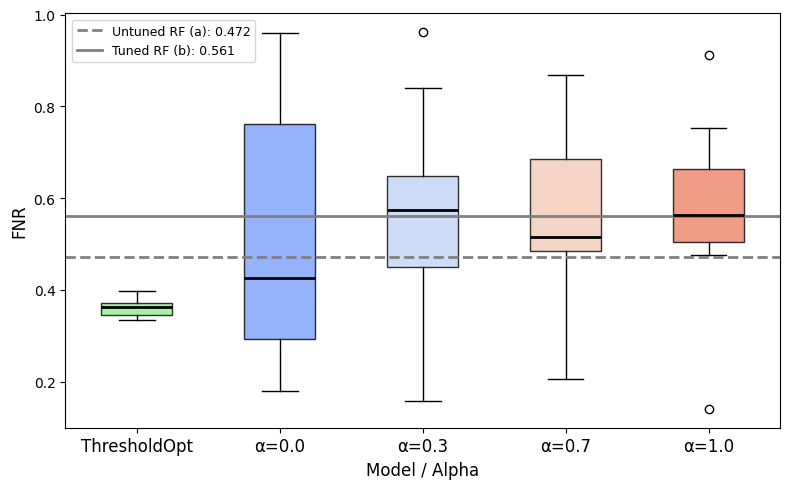

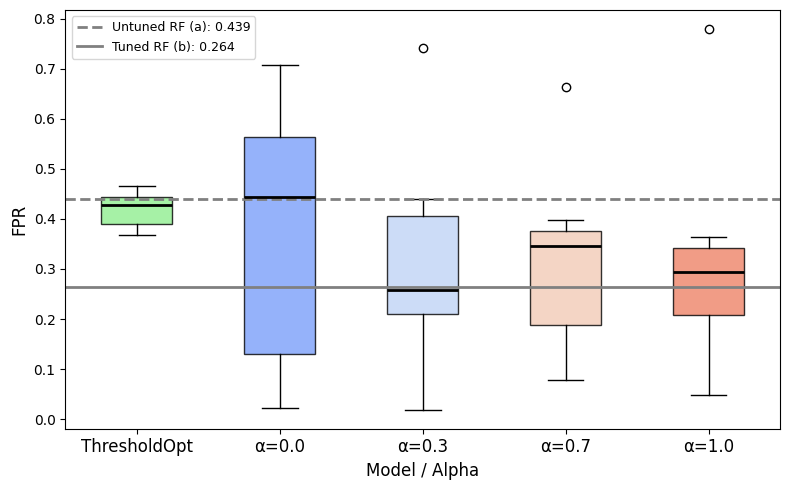

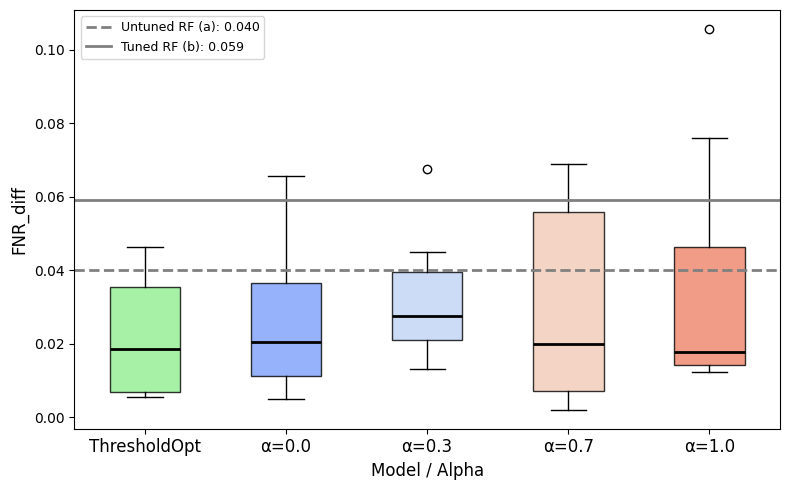

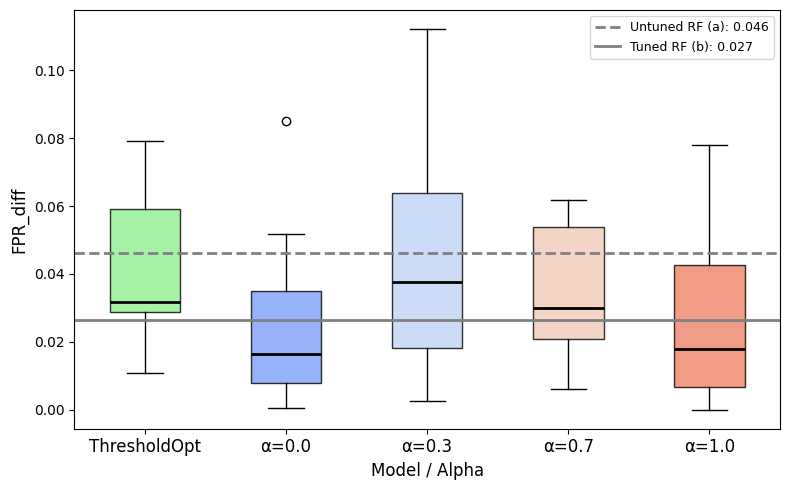

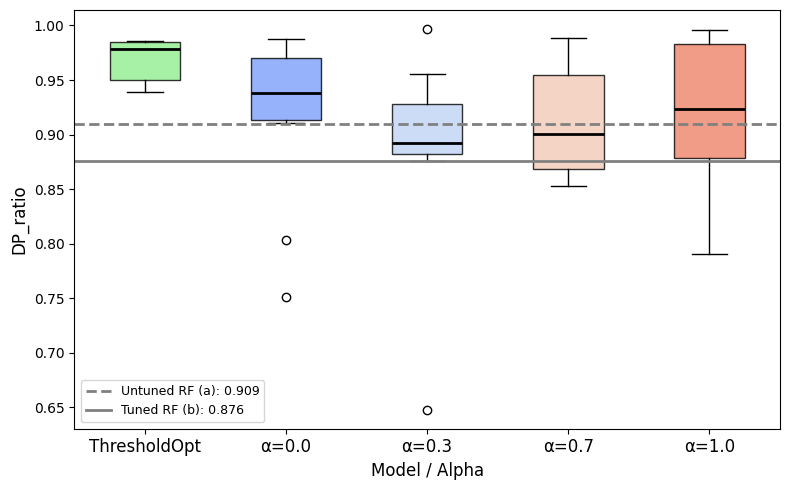

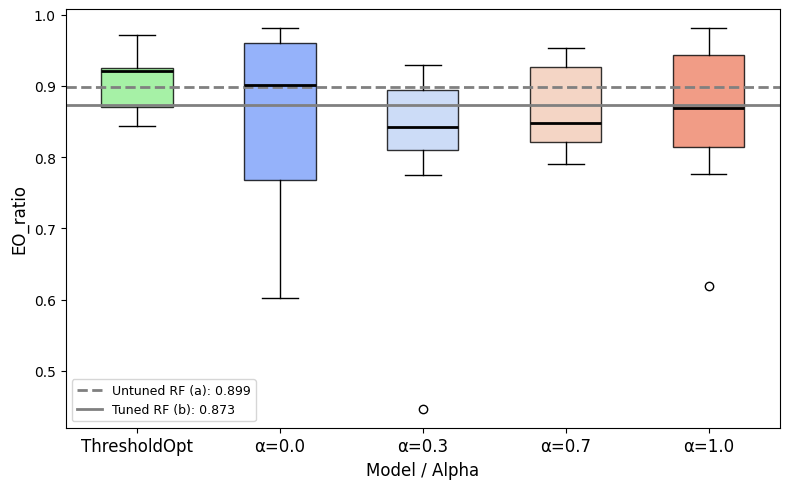

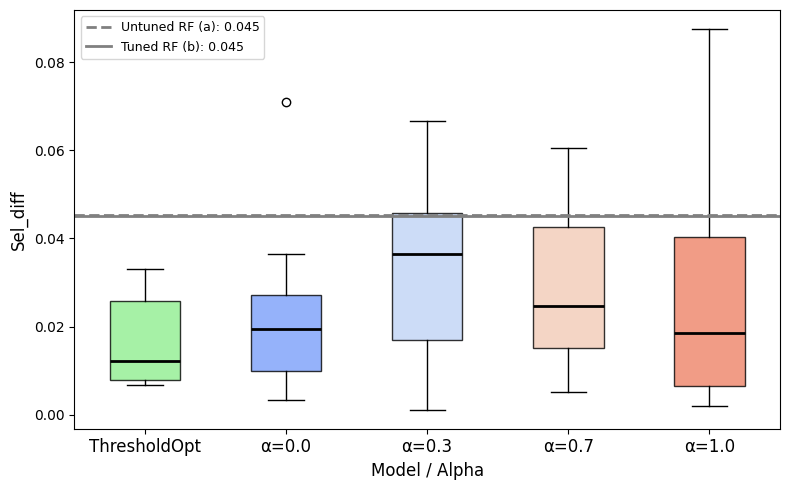

In [ ]:
N_SPLITS = 5
ALPHAS = [0.0, 0.3, 0.7, 1.0]
all_metric_keys = list(metric_dict.keys()) + list(FAIRNESS_FUNCS.keys())

# Containers for results
threshold_results = {k: [] for k in all_metric_keys}
afc_results_for_plot = afc_results

# Run N_SPLITS random train/test splits
for split_seed in range(N_SPLITS):
    # Split data
    X_train_split, X_test_split, y_train_split, y_test_split = train_test_split(
        x_numeric, y_raw, test_size=0.2, random_state=split_seed, shuffle=True
    )
    sensitive_train_split = X_train_split['gender_Female']
    sensitive_test_split = X_test_split['gender_Female']

    # Train hyperparameter-tuned RF
    tuned_rf = RandomForestClassifier(n_estimators=1000, max_depth=10, random_state=split_seed)
    tuned_rf.fit(X_train_split, y_train_split)
    y_pred_rf = tuned_rf.predict(X_test_split)

    # Fit ThresholdOptimizer
    # In medical context, minimizing FNR difference is critical (reduce false negatives)
    postproc = ThresholdOptimizer(
        estimator=tuned_rf,
        constraints="equalized_odds",  # balances FPR/FNR across groups
        prefit=True
    )
    postproc.fit(X_train_split, y_train_split, sensitive_features=sensitive_train_split)
    y_pred_post = postproc.predict(X_test_split, sensitive_features=sensitive_test_split)

    # Compute metrics for ThresholdOptimizer
    m_post = compute_all_metrics(y_test_split, y_pred_post, sensitive_test_split)
    for k in metric_dict:
        threshold_results[k].append(m_post['overall'][k])
    for k in FAIRNESS_FUNCS:
        threshold_results[k].append(m_post[k])

# Visualization
for metric in all_metric_keys:
    fig, ax = plt.subplots(figsize=(8,5))

    # Data for plotting
    data_to_plot = [threshold_results[metric]] + [afc_results_for_plot[a][metric] for a in ALPHAS]

    # Boxplot
    positions = range(len(data_to_plot))
    bp = ax.boxplot(
        data_to_plot,
        patch_artist=True,
        medianprops=dict(color='black', lw=2),
        positions=positions
    )
    colors = ['lightgreen'] + sns.color_palette("coolwarm", len(ALPHAS))
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.8)

    # Horizontal reference lines
    tuned_val = metrics_tuned['overall'][metric] if metric in metric_dict else metrics_tuned[metric]
    untuned_val = metrics_baseline['overall'][metric] if metric in metric_dict else metrics_baseline[metric]

    ax.axhline(untuned_val, color='gray', ls='--', lw=2, label=f'Untuned RF (a): {untuned_val:.3f}')
    ax.axhline(tuned_val, color='gray', ls='-', lw=2, label=f'Tuned RF (b): {tuned_val:.3f}')

    ax.set_xticks(range(len(data_to_plot)))
    ax.set_xticklabels(['ThresholdOpt'] + [f'α={a}' for a in ALPHAS], fontsize=12)
    ax.set_xlabel('Model / Alpha', fontsize=12)
    ax.set_ylabel(metric, fontsize=12)
    ax.legend(fontsize=9)
    plt.tight_layout()
    plt.show()


## Takeaways

The tuned Random Forest gives the strongest gain in accuracy and precision but increases missed readmissions. Adversarial debiasing improves recall and reduces some group disparities at a cost in predictive performance.

ThresholdOptimizer gives the strongest recall and low FNR with stable fairness across splits, but its FPR is higher. The main result is therefore a clear trade-off: reducing missed high-risk patients requires accepting more false alarms.
